In [10]:
"""
Third attempt at training the models. We now use ALL the dataset to train models and use k-fold, so no test sets. We used here for the label division 
NTSS < 3.5 - crypt < 50. 
The random state for the shuffled of the cross validation is set to 15.

"""

'\nThird attempt at training the models. We now use ALL the dataset to train models and use k-fold, so no test sets. We used here for the label division \nNTSS < 3.5 - crypt < 50. \nThe random state for the shuffled of the cross validation is set to 15.\n\n'

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [12]:
from src.utils.io import load_excel

DATA_DIR = PROJECT_ROOT / "data"

train = load_excel(
    DATA_DIR /
    "processed" /
    "processed_elec-prot" /
    "augmented_total_3.xlsx"
)

In [13]:
features = ["MDR", "PW", "Frequency", "NoP", "TD", "Particle", "Target"]

X_train = train[features]
y_train = train["Endpoint"]

titles = train["Title"]

In [14]:
# RANDOM FOREST

In [15]:
from src.models.random_forest import train_random_forest
model = train_random_forest(X_train, y_train, n = 2000, msl = 10, mss = 20)

In [16]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model, X_train, y_train, titles, seed=15)


=== Fold composition summary ===

Fold 1:
  Train groups: 19
  Test groups:  3
  Train samples: 244
  Test samples:  96

Fold 2:
  Train groups: 18
  Test groups:  4
  Train samples: 280
  Test samples:  60

Fold 3:
  Train groups: 17
  Test groups:  5
  Train samples: 276
  Test samples:  64

Fold 4:
  Train groups: 17
  Test groups:  5
  Train samples: 272
  Test samples:  68

Fold 5:
  Train groups: 17
  Test groups:  5
  Train samples: 288
  Test samples:  52



{'f1_scores': array([0.79699248, 0.75362319, 0.44444444, 0.46153846, 0.44444444]),
 'accuracy_scores': array([0.71875   , 0.71666667, 0.6875    , 0.38235294, 0.61538462]),
 'f1_mean': np.float64(0.580208604007231),
 'f1_std': np.float64(0.16000892740800338),
 'acc_mean': np.float64(0.6241308446455506),
 'acc_std': np.float64(0.12654198030664612)}

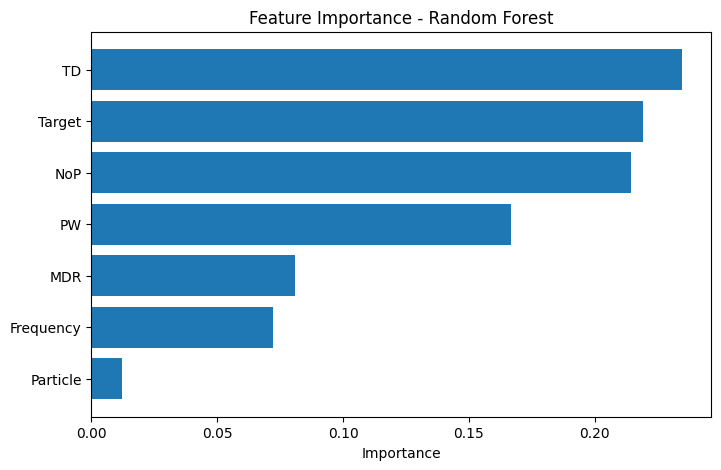

In [17]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance

feature_importance = get_feature_importance(model, features)
plot_feature_importance(feature_importance, "Random Forest")

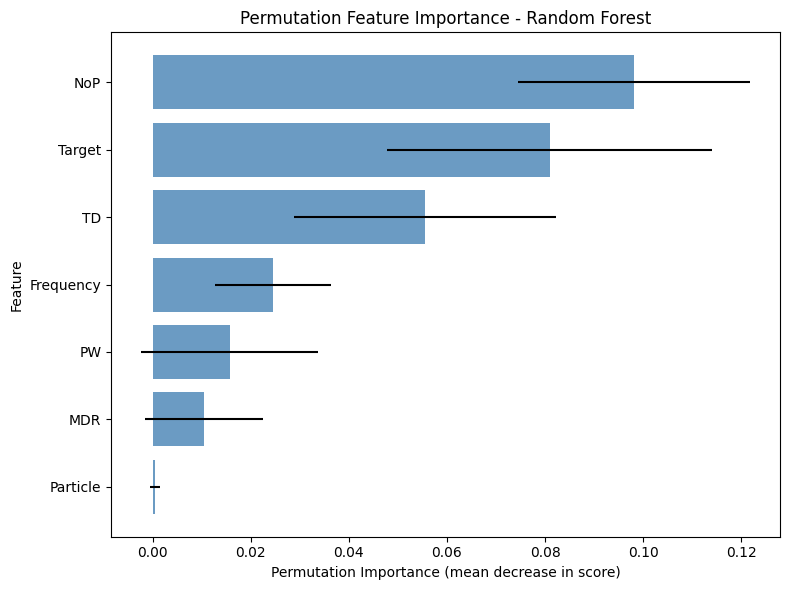

In [18]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="Random Forest"
)


In [19]:
# XGBOOST

In [20]:
from src.models.xgboost import train_xgb

model_xgb = train_xgb(X_train, y_train, n=500, md = 4, ra= 0.1, rl = 2)

In [21]:
from src.models.cross_validation import cross_validate_grouped_stratified
cross_validate_grouped_stratified(model_xgb, X_train, y_train, titles, seed=15)


=== Fold composition summary ===

Fold 1:
  Train groups: 19
  Test groups:  3
  Train samples: 244
  Test samples:  96

Fold 2:
  Train groups: 18
  Test groups:  4
  Train samples: 280
  Test samples:  60

Fold 3:
  Train groups: 17
  Test groups:  5
  Train samples: 276
  Test samples:  64

Fold 4:
  Train groups: 17
  Test groups:  5
  Train samples: 272
  Test samples:  68

Fold 5:
  Train groups: 17
  Test groups:  5
  Train samples: 288
  Test samples:  52



{'f1_scores': array([0.62068966, 0.75949367, 0.28070175, 0.42105263, 0.5106383 ]),
 'accuracy_scores': array([0.54166667, 0.68333333, 0.359375  , 0.35294118, 0.55769231]),
 'f1_mean': np.float64(0.5185152019791485),
 'f1_std': np.float64(0.16408929000123543),
 'acc_mean': np.float64(0.49900169683257917),
 'acc_std': np.float64(0.12654827517265527)}

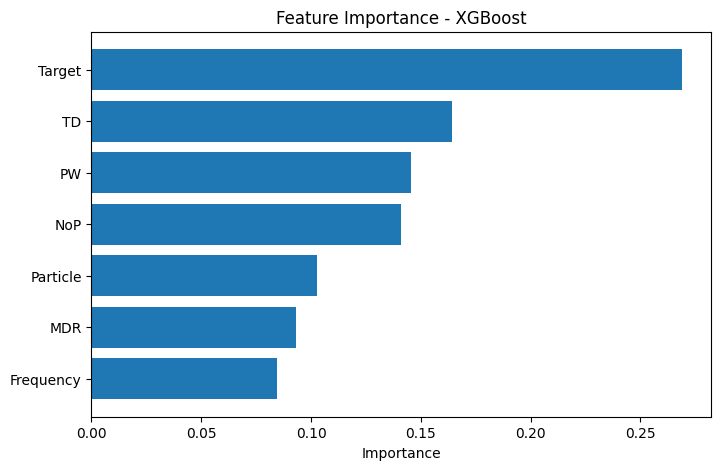

In [ ]:
from src.models.evaluation import get_feature_importance
from src.visualization.plots import plot_feature_importance

feature_importance_xgb = get_feature_importance(model_xgb, features)
plot_feature_importance(feature_importance_xgb, "XGBoost")

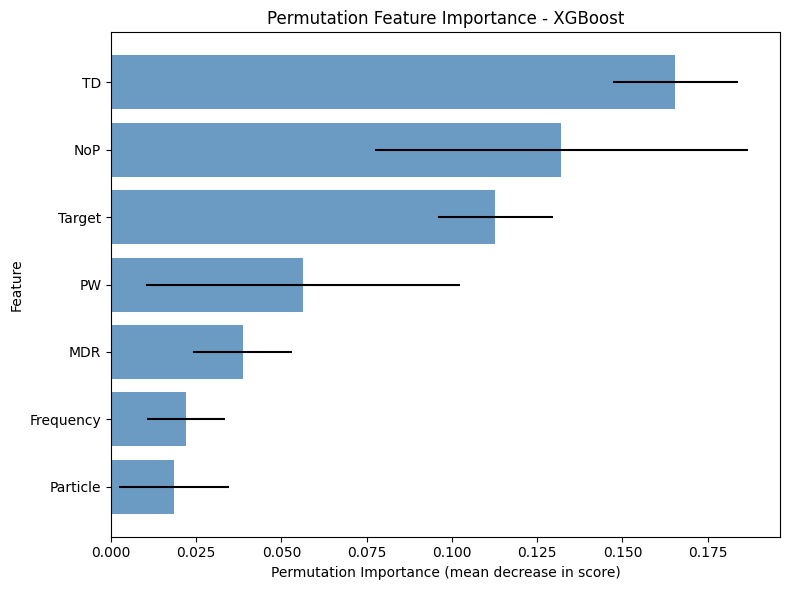

In [23]:
from src.visualization.plots import grouped_permutation_importance

imp = grouped_permutation_importance(
    model=model_xgb,
    X=X_train,
    y=y_train,
    titles=titles,
    folds=5,
    n_repeats=30,
    plot=True,
    model_name="XGBoost"
)

In [24]:
# Neural Network

In [25]:
"""
from src.models.neural_network import build_mlp
model_nn = build_mlp(input_dim=X_train.shape[1])
"""

'\nfrom src.models.neural_network import build_mlp\nmodel_nn = build_mlp(input_dim=X_train.shape[1])\n'

In [26]:
"""
from sklearn.model_selection import train_test_split

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train
)


from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_data=(X_test_nn, y_test_nn),
    epochs=200,
    batch_size=32,
    callbacks=[es],
    verbose=1
)
"""

"\nfrom sklearn.model_selection import train_test_split\n\nX_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(\n    X_train, y_train, test_size=0.2, random_state=11, stratify=y_train\n)\n\n\nfrom tensorflow.keras.callbacks import EarlyStopping\nes = EarlyStopping(\n    monitor='val_loss',\n    patience=20,\n    restore_best_weights=True\n)\n\nhistory = model_nn.fit(\n    X_train, y_train,\n    validation_data=(X_test_nn, y_test_nn),\n    epochs=200,\n    batch_size=32,\n    callbacks=[es],\n    verbose=1\n)\n"

In [27]:
"""
from src.models.evaluation import evaluate_model_keras
evaluate_model_keras(model_nn, X_test, y_test)
"""

'\nfrom src.models.evaluation import evaluate_model_keras\nevaluate_model_keras(model_nn, X_test, y_test)\n'